In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# NLP
import re
from collections import Counter

# Optional: spaCy or NLTK depending on what you install
# spaCy example: free and works well once model downloaded
import spacy
# Make sure to download model in your environment first:
# !python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

In [3]:
# Adjust path to your CSV
df = pd.read_csv("wwe2k_team_data_uk.csv")

# Quick look
df.head()

,team_id,team_name,sales_units_uk,profit_margin_pct,avg_age_group,gender_mix_pct_male,gender_mix_pct_female,region,occupation_type,fan_comments,time_period
0,1,Alpha Crew,1250,18.5,25-34,72.0,28.0,North West,Student,"Love the new roster, great value for money",2025-Q1
1,2,Steel Syndicate,980,14.2,35-44,65.0,35.0,London,Professional,Solid gameplay but needs better online,2025-Q1
2,3,Urban Outlaws,760,12.0,18-24,80.0,20.0,Scotland,Blue-collar,High energy matches; graphics are okay,2025-Q1
3,4,Royal Reign,500,10.0,45+,55.0,45.0,South East,Retired,"Too many DLCs, but nostalgic vibe",2025-Q1


In [4]:
# Drop rows with missing critical values
df_clean = df.dropna(subset=["sales_units_uk", "profit_margin_pct", "fan_comments"])

# Create numeric features from demographics if needed
# Example: encode age group ordinally
age_order = {"18-24": 1, "25-34": 2, "35-44": 3, "45+": 4}
df_clean["age_group_code"] = df_clean["avg_age_group"].map(age_order)

# Region encoding: simple one-hot
df_clean = pd.get_dummies(df_clean, columns=["region"], prefix="reg")

# Occupation encoding: one-hot
df_clean = pd.get_dummies(df_clean, columns=["occupation_type"], prefix="occ")

# Gender mix: numeric already
# If only male given, compute female or vice versa
if "gender_mix_pct_female" not in df_clean.columns and "gender_mix_pct_male" in df_clean.columns:
    df_clean["gender_mix_pct_female"] = 100 - df_clean["gender_mix_pct_male"]

In [5]:
def extract_keywords(text, top_n=5):
    # Lowercase, remove simple punctuation
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    doc = nlp(text)
    # Use noun chunks or named entities; here nouns and proper nouns
    keywords = [token.lemma_ for token in doc 
                if token.pos_ in {"NOUN", "PROPN", "ADJ"} and not token.is_stop]
    # Return most common
    counts = Counter(keywords)
    return [k for k, _ in counts.most_common(top_n)]

# Add a feature: number of keywords or specific keyword flags
keyword_lists = df_clean["fan_comments"].apply(lambda x: extract_keywords(x, top_n=10))
df_clean["num_keywords"] = keyword_lists.apply(len)

# Create a few keyword flags, e.g., whether 'gameplay', 'dlc', 'graphics' appear
target_keywords = ["gameplay", "dlc", "graphics", "value", "online", "nostalgic"]
for kw in target_keywords:
    df_clean[f"kw_{kw}"] = keyword_lists.apply(lambda kws: int(kw in kws))

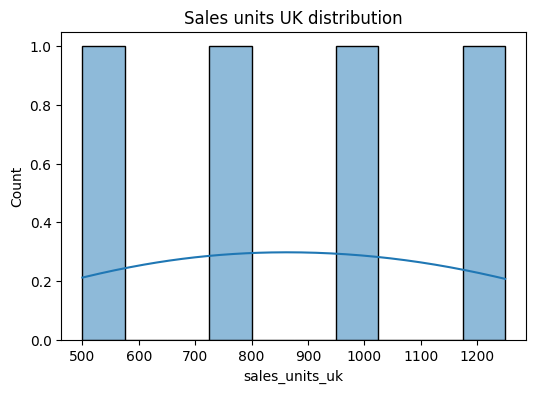

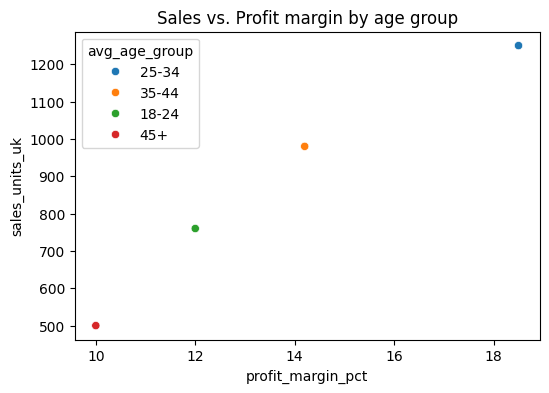

In [6]:
# Sales distribution
plt.figure(figsize=(6,4))
sns.histplot(df_clean["sales_units_uk"], bins=10, kde=True)
plt.title("Sales units UK distribution")
plt.show()

# Profit margin vs. sales
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x="profit_margin_pct", y="sales_units_uk", hue="avg_age_group")
plt.title("Sales vs. Profit margin by age group")
plt.show()

In [7]:
# Features to use
features = [
    "profit_margin_pct", "age_group_code", "gender_mix_pct_male",
    "num_keywords"
] + [col for col in df_clean.columns if col.startswith("reg_") or col.startswith("occ_") or col.startswith("kw_")]

# Drop rows with any NaN in features
df_model = df_clean.dropna(subset=features + ["sales_units_uk"])

X = df_model[features]
y = df_model["sales_units_uk"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
print(X.shape)

(4, 18)


In [11]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", key=lambda col: col.abs(), ascending=False)
coef_df.head(15)

,feature,coefficient
0,profit_margin_pct,73.589939
15,kw_value,10.260963
5,reg_North West,10.260963
11,occ_Student,10.260963
3,num_keywords,6.893678
6,reg_Scotland,-6.814124
8,occ_Blue-collar,-6.814124
2,gender_mix_pct_male,4.083273
10,occ_Retired,-3.446839
17,kw_nostalgic,-3.446839


In [12]:
y = df_model["profit_margin_pct"]
# rest same: split, fit, evaluate